# AI Post-Disaster Damage Mapping



## GPU & PyTorch Check

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
import os

folders = [
    "data",
    "models",
    "src",
    "outputs"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created:")
for folder in folders:
    print(f"✓ {folder}/")

Project folders created:
✓ data/
✓ models/
✓ src/
✓ outputs/


In [ ]:
!pip install -q ultralytics opencv-python matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 7.3 MB/s eta 0:00:00


In [ ]:
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import ultralytics

print("OpenCV:", cv2.__version__)
print("Pandas:", pd.__version__)
print("Ultralytics:", ultralytics.__version__)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
OpenCV: 5.0.0
Pandas: 2.2.2
Ultralytics: 8.4.120


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT_PATH = "/content/drive/MyDrive/AkashDristi"
DATA_PATH = os.path.join(PROJECT_PATH, "xbd")

os.makedirs(DATA_PATH, exist_ok=True)

print("Project:", PROJECT_PATH)
print("Dataset:", DATA_PATH)
print("Dataset folder exists:", os.path.exists(DATA_PATH))

Project: /content/drive/MyDrive/AkashDristi
Dataset: /content/drive/MyDrive/AkashDristi/xbd
Dataset folder exists: True


In [ ]:
TRAIN_URL = "https://download.xview2.org/train_images_labels_targets.tar.gz?Expires=1786794095&Signature=fa0npPwNvnlCeePP-E3h1pOd48LdqMcR8zuQ-4ZRNbmu~dLWdU-aUf2TmhnvaSiopWsWtQUBLLTXr6igJj2QsheIpikRuo3ASV7jGxKrbg5Xhe-6Vi16QnTkGs4nPzmCyMhB8ubo~LsqlN5mbo5HhGdQcUMfBC7AFWgmhS6e~sOI0iISs-Dhvp~dYj2rcC0Gkg3XROeiq1rBnn6CFkeoH06DjUC8B0dudSDld-~r1Jo6FL6E9pypVxlv68NLKtS157lY6M53-1cif54pBp91teRy8fDEVwPla5Kq8OsB5XgxmgL86mwETZvr13fuSHxy1tZIE4AZ6yP8QsGDIQA5rg__&Key-Pair-Id=APKAIKGDJB5C3XUL2DXQ"

print(TRAIN_URL)

https://download.xview2.org/train_images_labels_targets.tar.gz?Expires=1786794095&Signature=fa0npPwNvnlCeePP-E3h1pOd48LdqMcR8zuQ-4ZRNbmu~dLWdU-aUf2TmhnvaSiopWsWtQUBLLTXr6igJj2QsheIpikRuo3ASV7jGxKrbg5Xhe-6Vi16QnTkGs4nPzmCyMhB8ubo~LsqlN5mbo5HhGdQcUMfBC7AFWgmhS6e~sOI0iISs-Dhvp~dYj2rcC0Gkg3XROeiq1rBnn6CFkeoH06DjUC8B0dudSDld-~r1Jo6FL6E9pypVxlv68NLKtS157lY6M53-1cif54pBp91teRy8fDEVwPla5Kq8OsB5XgxmgL86mwETZvr13fuSHxy1tZIE4AZ6yP8QsGDIQA5rg__&Key-Pair-Id=APKAIKGDJB5C3XUL2DXQ


In [ ]:
import os

DATA_PATH = "/content/drive/MyDrive/AkashDristi/xbd"

os.makedirs(DATA_PATH, exist_ok=True)

print(DATA_PATH)

/content/drive/MyDrive/AkashDristi/xbd


In [ ]:
TRAIN_URL = "https://download.xview2.org/train_images_labels_targets.tar.gz?Expires=1786794095&Signature=fa0npPwNvnlCeePP-E3h1pOd48LdqMcR8zuQ-4ZRNbmu~dLWdU-aUf2TmhnvaSiopWsWtQUBLLTXr6igJj2QsheIpikRuo3ASV7jGxKrbg5Xhe-6Vi16QnTkGs4nPzmCyMhB8ubo~LsqlN5mbo5HhGdQcUMfBC7AFWgmhS6e~sOI0iISs-Dhvp~dYj2rcC0Gkg3XROeiq1rBnn6CFkeoH06DjUC8B0dudSDld-~r1Jo6FL6E9pypVxlv68NLKtS157lY6M53-1cif54pBp91teRy8fDEVwPla5Kq8OsB5XgxmgL86mwETZvr13fuSHxy1tZIE4AZ6yP8QsGDIQA5rg__&Key-Pair-Id=APKAIKGDJB5C3XUL2DXQ"

In [ ]:
!wget -O "/content/drive/MyDrive/AkashDristi/xbd/train_images_labels_targets.tar.gz" "$TRAIN_URL"

--2026-08-15 11:32:31--  https://download.xview2.org/train_images_labels_targets.tar.gz?Expires=1786794095&Signature=fa0npPwNvnlCeePP-E3h1pOd48LdqMcR8zuQ-4ZRNbmu~dLWdU-aUf2TmhnvaSiopWsWtQUBLLTXr6igJj2QsheIpikRuo3ASV7jGxKrbg5Xhe-6Vi16QnTkGs4nPzmCyMhB8ubo~LsqlN5mbo5HhGdQcUMfBC7AFWgmhS6e~sOI0iISs-Dhvp~dYj2rcC0Gkg3XROeiq1rBnn6CFkeoH06DjUC8B0dudSDld-~r1Jo6FL6E9pypVxlv68NLKtS157lY6M53-1cif54pBp91teRy8fDEVwPla5Kq8OsB5XgxmgL86mwETZvr13fuSHxy1tZIE4AZ6yP8QsGDIQA5rg__&Key-Pair-Id=APKAIKGDJB5C3XUL2DXQ
Resolving download.xview2.org (download.xview2.org)... 3.164.85.118, 3.164.85.16, 3.164.85.70, ...
Connecting to download.xview2.org (download.xview2.org)|3.164.85.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8381754539 (7.8G) [application/x-tar]
Saving to: ‘/content/drive/MyDrive/AkashDristi/xbd/train_images_labels_targets.tar.gz’

/content/drive/MyDr 100%[===================>]   7.81G  20.5MB/s    in 6m 46s  

2026-08-15 11:39:19 (19.7 MB/s) - ‘/content/drive/MyDriv

In [ ]:
import os

DATA_PATH = "/content/drive/MyDrive/AkashDristi/xbd"

print("Files in xbd folder:")
for file in os.listdir(DATA_PATH):
    print(file)

Files in xbd folder:
train_images_labels_targets.tar.gz


In [ ]:
import os

file_path = os.path.join(
    DATA_PATH,
    "train_images_labels_targets.tar.gz"
)

size_gb = os.path.getsize(file_path) / (1024 ** 3)

print(f"Dataset size: {size_gb:.2f} GB")

Dataset size: 7.81 GB


In [ ]:
!tar -tzf "/content/drive/MyDrive/AkashDristi/xbd/train_images_labels_targets.tar.gz" | head -40

train/
train/labels/
train/labels/midwest-flooding_00000172_post_disaster.json
train/labels/hurricane-matthew_00000052_pre_disaster.json
train/labels/mexico-earthquake_00000017_post_disaster.json
train/labels/hurricane-michael_00000099_post_disaster.json
train/labels/hurricane-florence_00000387_post_disaster.json
train/labels/hurricane-florence_00000024_pre_disaster.json
train/labels/hurricane-matthew_00000132_pre_disaster.json
train/labels/hurricane-michael_00000205_post_disaster.json
train/labels/midwest-flooding_00000222_pre_disaster.json
train/labels/hurricane-harvey_00000242_post_disaster.json
train/labels/socal-fire_00001215_post_disaster.json
train/labels/socal-fire_00000873_pre_disaster.json
train/labels/palu-tsunami_00000109_post_disaster.json
train/labels/hurricane-matthew_00000332_pre_disaster.json
train/labels/socal-fire_00000565_post_disaster.json
train/labels/socal-fire_00001402_pre_disaster.json
train/labels/socal-fire_00000398_post_disaster.json
train/labels/palu-tsunam

In [ ]:
!tar -tzf "/content/drive/MyDrive/AkashDristi/xbd/train_images_labels_targets.tar.gz" | grep -E '^train/' | grep -v 'labels/' | head -30

train/
train/images/
train/images/hurricane-michael_00000239_post_disaster.png
train/images/socal-fire_00000103_pre_disaster.png
train/images/midwest-flooding_00000386_post_disaster.png
train/images/socal-fire_00001387_pre_disaster.png
train/images/guatemala-volcano_00000025_pre_disaster.png
train/images/hurricane-michael_00000304_post_disaster.png
train/images/socal-fire_00000343_pre_disaster.png
train/images/midwest-flooding_00000216_post_disaster.png
train/images/hurricane-florence_00000424_pre_disaster.png
train/images/midwest-flooding_00000299_post_disaster.png
train/images/hurricane-matthew_00000156_pre_disaster.png
train/images/socal-fire_00000261_pre_disaster.png
train/images/hurricane-florence_00000392_post_disaster.png
train/images/palu-tsunami_00000044_pre_disaster.png
train/images/socal-fire_00000639_post_disaster.png
train/images/mexico-earthquake_00000143_post_disaster.png
train/images/hurricane-harvey_00000366_pre_disaster.png
train/images/midwest-flooding_00000183_post_

In [ ]:
import os

ARCHIVE = "/content/drive/MyDrive/AkashDristi/xbd/train_images_labels_targets.tar.gz"
EXTRACT_PATH = "/content/drive/MyDrive/AkashDristi/xbd"

print("Starting extraction...")

Starting extraction...


In [ ]:
!tar -xzf "$ARCHIVE" -C "$EXTRACT_PATH"

In [ ]:
import os

TRAIN_PATH = "/content/drive/MyDrive/AkashDristi/xbd/train"
IMAGE_PATH = os.path.join(TRAIN_PATH, "images")
LABEL_PATH = os.path.join(TRAIN_PATH, "labels")

print("Images folder exists:", os.path.exists(IMAGE_PATH))
print("Labels folder exists:", os.path.exists(LABEL_PATH))

print("\nNumber of images:", len(os.listdir(IMAGE_PATH)))
print("Number of labels:", len(os.listdir(LABEL_PATH)))

Images folder exists: True
Labels folder exists: True

Number of images: 5598
Number of labels: 5598


In [ ]:
import os

images = [
    f for f in os.listdir(IMAGE_PATH)
    if f.endswith(".png")
]

sample_image = images[0]

print("Sample image:")
print(sample_image)

Sample image:
hurricane-michael_00000239_post_disaster.png


Image size: (1024, 1024)
Image mode: RGB


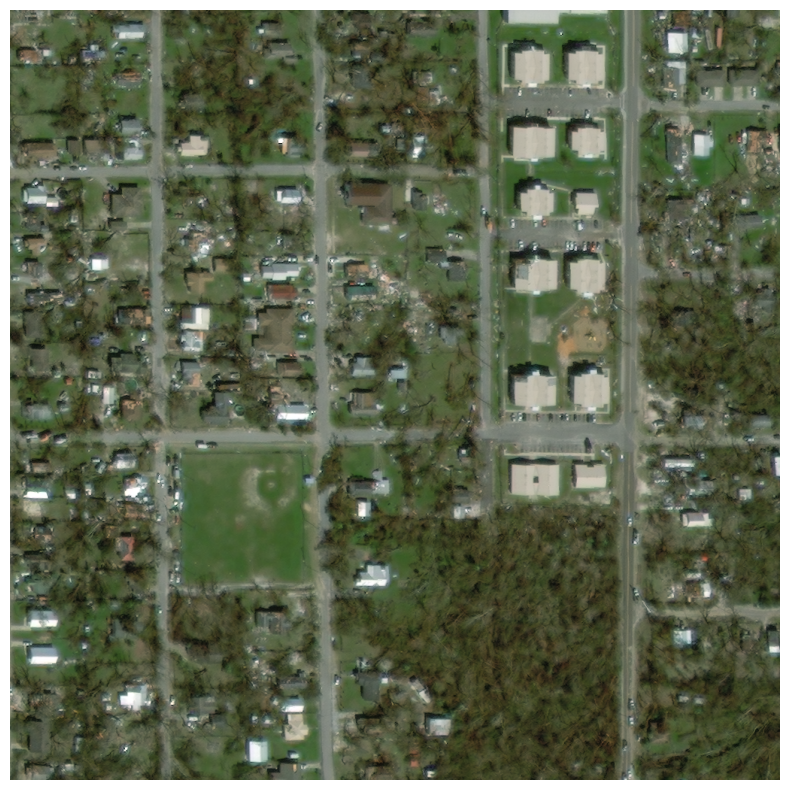

Image: hurricane-michael_00000239_post_disaster.png
Label: hurricane-michael_00000239_post_disaster.json
Label exists: True
dict_keys(['features', 'metadata'])


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image_file = os.path.join(IMAGE_PATH, sample_image)

image = Image.open(image_file)

print("Image size:", image.size)
print("Image mode:", image.mode)

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")
plt.show()

import json

label_name = os.path.splitext(sample_image)[0] + ".json"
label_file = os.path.join(LABEL_PATH, label_name)

print("Image:", sample_image)
print("Label:", label_name)
print("Label exists:", os.path.exists(label_file))
with open(label_file, "r") as f:
    annotation = json.load(f)

print(annotation.keys())

In [ ]:
import json

print(json.dumps(annotation["metadata"], indent=2))


{
  "sensor": "GEOEYE01",
  "provider_asset_type": "GEOEYE01",
  "gsd": 2.0711906,
  "capture_date": "2018-10-13T16:48:15.000Z",
  "off_nadir_angle": 28.86673,
  "pan_resolution": 0.5171161,
  "sun_azimuth": 163.92638,
  "sun_elevation": 50.756794,
  "target_azimuth": 112.555626,
  "disaster": "hurricane-michael",
  "disaster_type": "wind",
  "catalog_id": "105001001292E000",
  "original_width": 1024,
  "original_height": 1024,
  "width": 1024,
  "height": 1024,
  "id": "MjU0NjI4MQ.7blCGLCK-n1pdBcqikQ3-5T2Iqs",
  "img_name": "hurricane-michael_00000239_post_disaster.png"
}


In [ ]:
print(type(annotation["features"]))

<class 'dict'>


In [ ]:
# ============================================================
# AKASHDRISTI
# Topic: Dataset Exploration
# Subtopic: Understanding xBD Annotation Structure
# Cell 13: Inspect the keys inside "features"
# ============================================================

print(annotation["features"].keys())

dict_keys(['lng_lat', 'xy'])


In [ ]:
# ============================================================
# AKASHDRISTI
# Topic: Dataset Exploration
# Subtopic: Inspecting Building Coordinates
# Cell 14: Examine the "xy" annotation data
# ============================================================

# Get the image-coordinate annotations
xy_features = annotation["features"]["xy"]

# Check what type of data we have
print("Type of xy features:", type(xy_features))

# Check how many entries are present
print("Number of xy entries:", len(xy_features))

Type of xy features: <class 'list'>
Number of xy entries: 146


# Dataset Exploration


### Inspecting a Single Building Annotation

In [ ]:
# ============================================================
# AKASHDRISTI
# Topic: Dataset Exploration
# Subtopic: Inspecting a Single Building Annotation
# Cell 16: Select the first building
# ============================================================

# Select the first building from the list of 146 annotations
first_building = xy_features[0]

# Display the first building annotation
print(first_building)

{'properties': {'feature_type': 'building', 'subtype': 'no-damage', 'uid': '3166a980-01b9-48f9-b495-671fa153ba67'}, 'wkt': 'POLYGON ((971.0000001361618 0.00233923960989422, 971.0000001371612 11.00000005043828, 954.0000001358339 11.00000005243724, 954.000000137583 0.002664089717760834, 971.0000001361618 0.00233923960989422))'}


### Extract Building Properties


In [ ]:
# ============================================================
# AKASHDRISTI
# Topic: Dataset Exploration
# Subtopic: Extracting Building Properties
# Cell 17: Inspect the first building's properties
# ============================================================

# Extract the properties of the first building
building_properties = first_building["properties"]

print("Feature type:", building_properties["feature_type"])
print("Damage subtype:", building_properties["subtype"])
print("Building UID:", building_properties["uid"])

Feature type: building
Damage subtype: no-damage
Building UID: 3166a980-01b9-48f9-b495-671fa153ba67


In [ ]:
# ============================================================
# AKASHDRISTI
# Topic: Dataset Exploration
# Subtopic: Understanding Building Geometry
# Cell 18: Extract the first building's polygon
# ============================================================

# Get the WKT (Well-Known Text) representation
# of the first building's polygon
building_wkt = first_building["wkt"]

print("Building WKT:")
print(building_wkt)

Building WKT:
POLYGON ((971.0000001361618 0.00233923960989422, 971.0000001371612 11.00000005043828, 954.0000001358339 11.00000005243724, 954.000000137583 0.002664089717760834, 971.0000001361618 0.00233923960989422))


In [ ]:
# ============================================================
# AKASHDRISTI
# Topic: Dataset Exploration
# Subtopic: Converting WKT to Polygon Coordinates
# Cell 19: Extract polygon points from WKT
# ============================================================

from shapely import wkt

# Convert the WKT text into a Shapely polygon object
building_polygon = wkt.loads(building_wkt)

# Get the polygon's coordinate points
polygon_coordinates = list(building_polygon.exterior.coords)

print("Polygon type:", building_polygon.geom_type)
print("Number of coordinate points:", len(polygon_coordinates))

print("\nCoordinate points:")
for point in polygon_coordinates:
    print(point)

Polygon type: Polygon
Number of coordinate points: 5

Coordinate points:
(971.0000001361618, 0.00233923960989422)
(971.0000001371612, 11.00000005043828)
(954.000000135834, 11.00000005243724)
(954.000000137583, 0.002664089717760834)
(971.0000001361618, 0.00233923960989422)


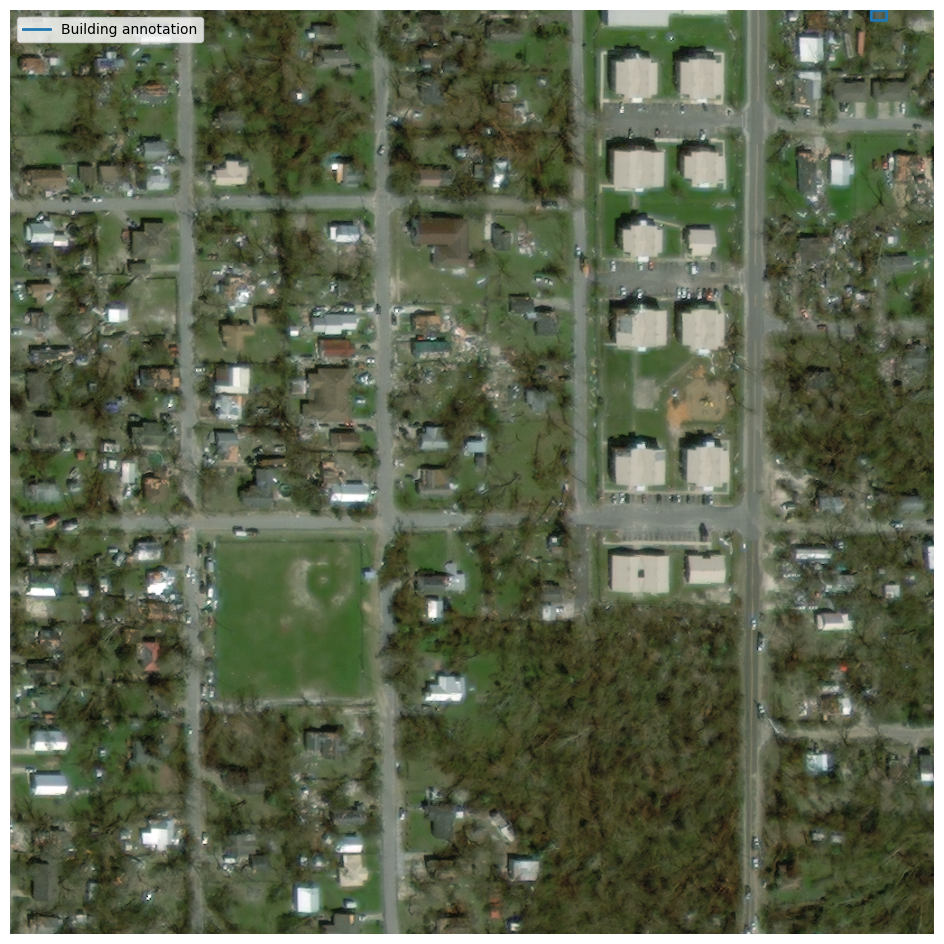

In [ ]:
# ============================================================
# AKASHDRISTI
# Topic: Dataset Exploration
# Subtopic: Visualizing Building Annotations
# Cell 20: Draw the first building polygon on the image
# ============================================================

import matplotlib.pyplot as plt

# Extract X and Y coordinates from the polygon
x_coordinates = [point[0] for point in polygon_coordinates]
y_coordinates = [point[1] for point in polygon_coordinates]

# Display the original image
plt.figure(figsize=(12, 12))
plt.imshow(image)

# Draw the building polygon
plt.plot(
    x_coordinates,
    y_coordinates,
    linewidth=2,
    label="Building annotation"
)

# Add a legend
plt.legend()

# Remove axis numbers for a cleaner image
plt.axis("off")

plt.show()

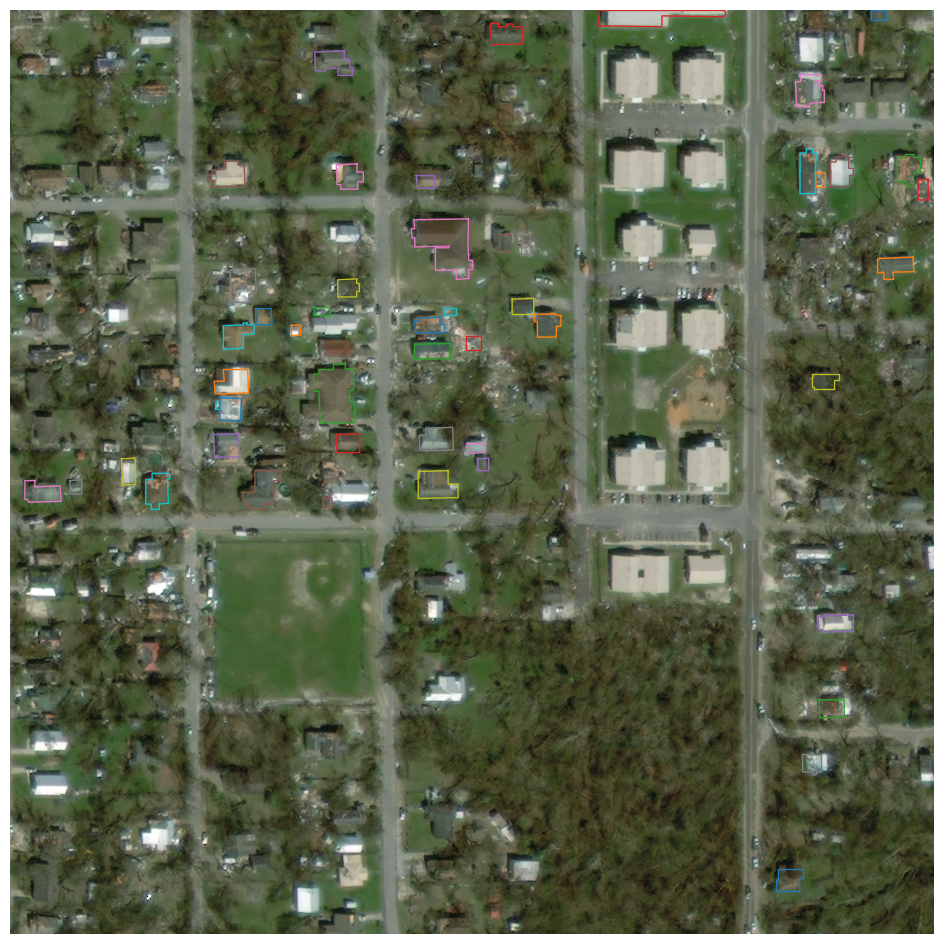

In [ ]:
# ============================================================
# AKASHDRISTI
# Topic: Dataset Exploration
# Subtopic: Visualizing Multiple Building Annotations
# Cell 21: Draw the first 50 building polygons
# ============================================================

import matplotlib.pyplot as plt

# Display the satellite image
plt.figure(figsize=(12, 12))
plt.imshow(image)

# Draw up to the first 50 building polygons
for building in xy_features[:50]:

    # Get the WKT polygon
    polygon = wkt.loads(building["wkt"])

    # Extract X and Y coordinates
    x = [point[0] for point in polygon.exterior.coords]
    y = [point[1] for point in polygon.exterior.coords]

    # Draw the building boundary
    plt.plot(x, y, linewidth=1)

# Hide axis numbers for a cleaner visualization
plt.axis("off")

plt.show()

In [ ]:
# ============================================================
# AKASHDRISTI
# Topic: Dataset Exploration
# Subtopic: Analyzing Damage Classes
# Cell 22: Count the damage labels in this image
# ============================================================

from collections import Counter

# Extract the damage subtype from every building
damage_labels = [
    building["properties"]["subtype"]
    for building in xy_features
]

# Count how many buildings belong to each damage class
damage_counts = Counter(damage_labels)

print("Damage classes in this image:\n")

for damage_class, count in damage_counts.items():
    print(f"{damage_class}: {count}")

Damage classes in this image:

no-damage: 79
minor-damage: 28
major-damage: 23
destroyed: 15
un-classified: 1


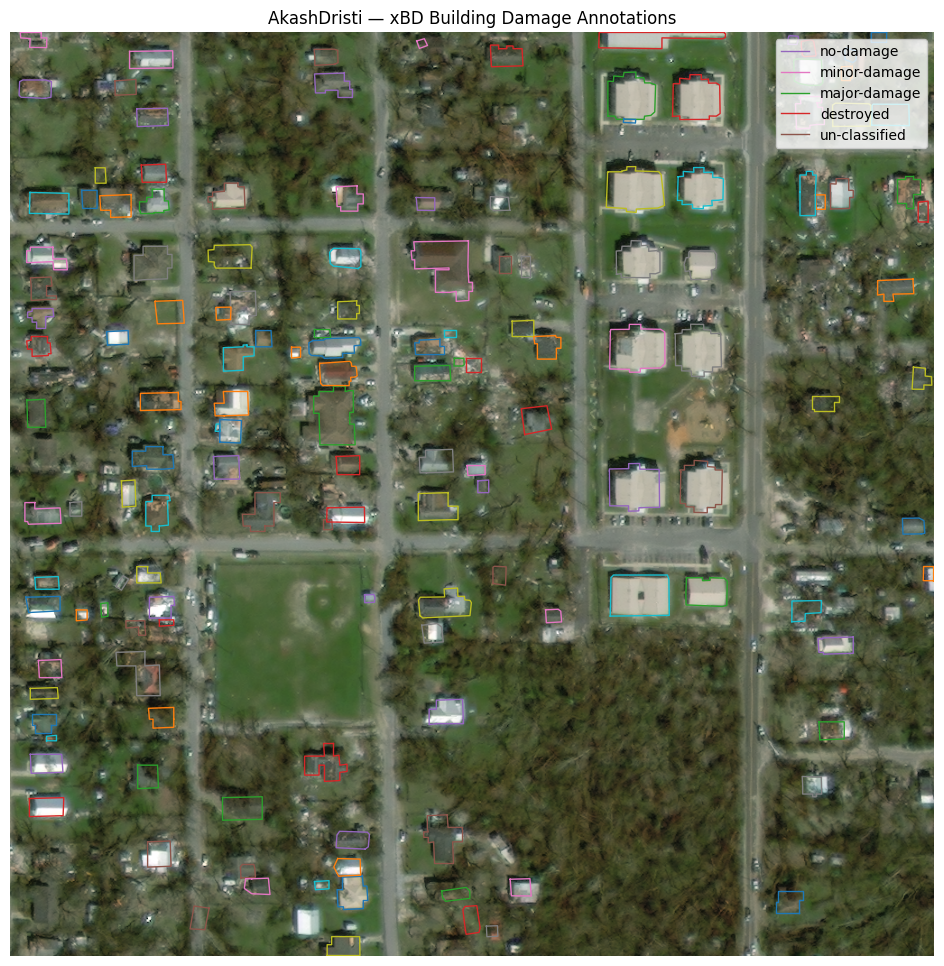

In [ ]:
# ============================================================
# AKASHDRISTI
# Topic: Dataset Exploration
# Subtopic: Visualizing Damage Classes
# Cell 23: Draw buildings according to their damage class
# ============================================================

import matplotlib.pyplot as plt

# Create the figure
plt.figure(figsize=(12, 12))

# Display the original satellite image
plt.imshow(image)

# Damage classes we want to visualize
damage_classes = [
    "no-damage",
    "minor-damage",
    "major-damage",
    "destroyed",
    "un-classified"
]

# Plot each building according to its damage class
for building in xy_features:

    # Get the damage label
    damage_class = building["properties"]["subtype"]

    # Skip anything unexpected
    if damage_class not in damage_classes:
        continue

    # Convert WKT into a polygon
    polygon = wkt.loads(building["wkt"])

    # Extract polygon coordinates
    x = [point[0] for point in polygon.exterior.coords]
    y = [point[1] for point in polygon.exterior.coords]

    # Draw the polygon
    plt.plot(
        x,
        y,
        linewidth=1,
        label=damage_class
    )

# Create a legend without duplicate entries
handles, labels = plt.gca().get_legend_handles_labels()

unique_labels = dict(zip(labels, handles))

plt.legend(
    unique_labels.values(),
    unique_labels.keys(),
    loc="upper right"
)

plt.title("AkashDristi — xBD Building Damage Annotations")

plt.axis("off")
plt.show()

In [ ]:
# ============================================================
# AKASHDRISTI
# Topic: Dataset Exploration
# Subtopic: Pre/Post Disaster Image Pairing
# Cell 24: Find the matching pre-disaster image
# ============================================================

# Replace "_post_disaster" with "_pre_disaster"
pre_disaster_name = sample_image.replace(
    "_post_disaster",
    "_pre_disaster"
)

pre_disaster_file = os.path.join(
    IMAGE_PATH,
    pre_disaster_name
)

print("Post-disaster image:")
print(sample_image)

print("\nMatching pre-disaster image:")
print(pre_disaster_name)

print("\nPre-disaster image exists:",
      os.path.exists(pre_disaster_file))

Post-disaster image:
hurricane-michael_00000239_post_disaster.png

Matching pre-disaster image:
hurricane-michael_00000239_pre_disaster.png

Pre-disaster image exists: True


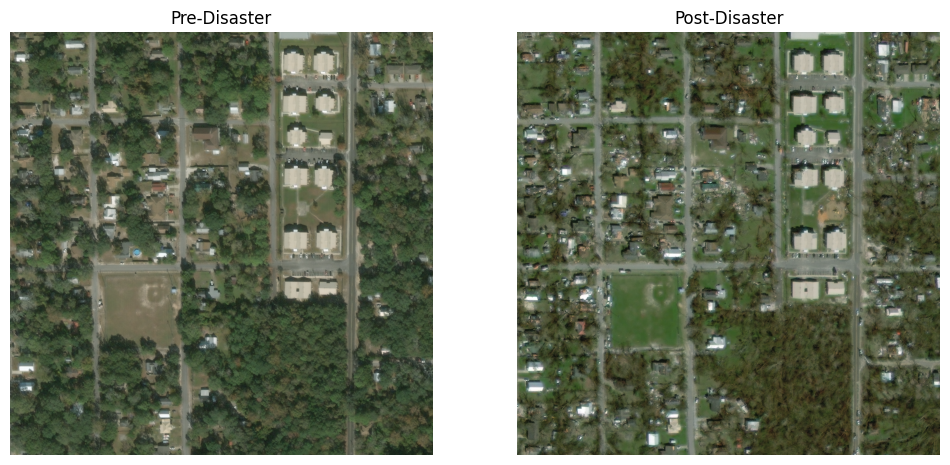

In [ ]:
# ============================================================
# AKASHDRISTI
# Topic: Dataset Exploration
# Subtopic: Pre/Post Disaster Image Comparison
# Cell 25: Display the same location before and after disaster
# ============================================================

from PIL import Image
import matplotlib.pyplot as plt

# Load the pre-disaster image
pre_image = Image.open(pre_disaster_file)

# Load the post-disaster image
post_image = Image.open(image_file)

# Create the figure
plt.figure(figsize=(12, 12))

# Display pre-disaster image
plt.subplot(1, 2, 1)
plt.imshow(pre_image)
plt.title("Pre-Disaster")
plt.axis("off")

# Display post-disaster image
plt.subplot(1, 2, 2)
plt.imshow(post_image)
plt.title("Post-Disaster")
plt.axis("off")

plt.show()

In [ ]:
# ============================================================
# AKASHDRISTI
# Topic: ML Data Preparation
# Subtopic: Dataset Size Analysis
# Cell 26: Count images and annotations
# ============================================================

import os

# Get all PNG images
image_files = [
    f for f in os.listdir(IMAGE_PATH)
    if f.endswith(".png")
]

# Get all JSON annotation files
label_files = [
    f for f in os.listdir(LABEL_PATH)
    if f.endswith(".json")
]

# Count pre/post images separately
pre_images = [
    f for f in image_files
    if "_pre_disaster" in f
]

post_images = [
    f for f in image_files
    if "_post_disaster" in f
]

print("Total images:", len(image_files))
print("Pre-disaster images:", len(pre_images))
print("Post-disaster images:", len(post_images))
print("Total JSON labels:", len(label_files))

Total images: 5598
Pre-disaster images: 2799
Post-disaster images: 2799
Total JSON labels: 5598


# ML Data Preparation

In [ ]:
# ============================================================
# AKASHDRISTI
# Topic: ML Data Preparation
# Subtopic: Development Dataset
# Cell 27: Create folders for our first experiment
# ============================================================

# Location for our first small ML experiment
DEV_PATH = os.path.join(PROJECT_PATH, "dev_dataset")

# Create separate folders for images and labels
DEV_IMAGE_PATH = os.path.join(DEV_PATH, "images")
DEV_LABEL_PATH = os.path.join(DEV_PATH, "labels")

os.makedirs(DEV_IMAGE_PATH, exist_ok=True)
os.makedirs(DEV_LABEL_PATH, exist_ok=True)

print("Development dataset folders created.")
print("Images:", DEV_IMAGE_PATH)
print("Labels:", DEV_LABEL_PATH)

Development dataset folders created.
Images: /content/drive/MyDrive/AkashDristi/dev_dataset/images
Labels: /content/drive/MyDrive/AkashDristi/dev_dataset/labels


In [ ]:
# ============================================================
# AKASHDRISTI
# Topic: ML Data Preparation
# Subtopic: Creating a Matched Development Dataset
# Cell 28: Select 200 pre/post disaster image pairs
# ============================================================

import random

# Use a fixed seed so we get the same 200 pairs every time
random.seed(42)

# Get all post-disaster images
post_images = [
    f for f in os.listdir(IMAGE_PATH)
    if f.endswith(".png") and "_post_disaster" in f
]

# Randomly select 200 post-disaster images
selected_post_images = random.sample(post_images, 200)

# Create the matching pre-disaster filenames
selected_pre_images = [
    f.replace("_post_disaster", "_pre_disaster")
    for f in selected_post_images
]

# Make sure every selected pair actually exists
valid_pairs = []

for post_image_name, pre_image_name in zip(
    selected_post_images,
    selected_pre_images
):
    post_exists = os.path.exists(
        os.path.join(IMAGE_PATH, post_image_name)
    )

    pre_exists = os.path.exists(
        os.path.join(IMAGE_PATH, pre_image_name)
    )

    if post_exists and pre_exists:
        valid_pairs.append(
            (pre_image_name, post_image_name)
        )

print("Selected post-disaster images:", len(selected_post_images))
print("Valid pre/post pairs:", len(valid_pairs))

Selected post-disaster images: 200
Valid pre/post pairs: 200


In [ ]:
# ============================================================
# AKASHDRISTI
# Topic: ML Data Preparation
# Subtopic: Creating the Development Dataset
# Cell 29: Copy selected images and JSON labels
# ============================================================

import shutil

copied_files = 0

for pre_image_name, post_image_name in valid_pairs:

    # --------------------------------------------------------
    # 1. Copy PRE-DISASTER image
    # --------------------------------------------------------
    pre_source = os.path.join(
        IMAGE_PATH,
        pre_image_name
    )

    pre_destination = os.path.join(
        DEV_IMAGE_PATH,
        pre_image_name
    )

    shutil.copy2(pre_source, pre_destination)

    # --------------------------------------------------------
    # 2. Copy POST-DISASTER image
    # --------------------------------------------------------
    post_source = os.path.join(
        IMAGE_PATH,
        post_image_name
    )

    post_destination = os.path.join(
        DEV_IMAGE_PATH,
        post_image_name
    )

    shutil.copy2(post_source, post_destination)

    # --------------------------------------------------------
    # 3. Copy PRE-DISASTER JSON label
    # --------------------------------------------------------
    pre_label_name = os.path.splitext(pre_image_name)[0] + ".json"

    pre_label_source = os.path.join(
        LABEL_PATH,
        pre_label_name
    )

    pre_label_destination = os.path.join(
        DEV_LABEL_PATH,
        pre_label_name
    )

    shutil.copy2(
        pre_label_source,
        pre_label_destination
    )

    # --------------------------------------------------------
    # 4. Copy POST-DISASTER JSON label
    # --------------------------------------------------------
    post_label_name = os.path.splitext(post_image_name)[0] + ".json"

    post_label_source = os.path.join(
        LABEL_PATH,
        post_label_name
    )

    post_label_destination = os.path.join(
        DEV_LABEL_PATH,
        post_label_name
    )

    shutil.copy2(
        post_label_source,
        post_label_destination
    )

    copied_files += 4

print("Dataset copying complete.")
print("Total files copied:", copied_files)

KeyboardInterrupt: 

In [ ]:
# ============================================================
# AKASHDRISTI
# Topic: ML Data Preparation
# Subtopic: Dataset Verification
# Cell 30: Verify development dataset files
# ============================================================

# Get all images in the development dataset
dev_images = [
    f for f in os.listdir(DEV_IMAGE_PATH)
    if f.endswith(".png")
]

# Get all JSON labels
dev_labels = [
    f for f in os.listdir(DEV_LABEL_PATH)
    if f.endswith(".json")
]

# Separate pre/post images
dev_pre_images = [
    f for f in dev_images
    if "_pre_disaster" in f
]

dev_post_images = [
    f for f in dev_images
    if "_post_disaster" in f
]

# Separate pre/post labels
dev_pre_labels = [
    f for f in dev_labels
    if "_pre_disaster" in f
]

dev_post_labels = [
    f for f in dev_labels
    if "_post_disaster" in f
]

print("Development Dataset Verification")
print("---------------------------------")
print("Total images:", len(dev_images))
print("Pre-disaster images:", len(dev_pre_images))
print("Post-disaster images:", len(dev_post_images))
print("Total labels:", len(dev_labels))
print("Pre-disaster labels:", len(dev_pre_labels))
print("Post-disaster labels:", len(dev_post_labels))

Development Dataset Verification
---------------------------------
Total images: 400
Pre-disaster images: 200
Post-disaster images: 200
Total labels: 400
Pre-disaster labels: 200
Post-disaster labels: 200


In [55]:
# ============================================================
# AKASHDRISTI
# Topic: ML Data Preparation
# Subtopic: Image-Label Verification
# Cell 31: Verify every image has a matching JSON label
# ============================================================

missing_labels = []

for image_name in dev_images:

    # Remove .png and create the expected JSON filename
    label_name = os.path.splitext(image_name)[0] + ".json"

    # Check whether the matching JSON exists
    if label_name not in dev_labels:
        missing_labels.append(image_name)

# Display the result
print("Total images checked:", len(dev_images))
print("Images missing labels:", len(missing_labels))

if len(missing_labels) == 0:
    print("✓ Every image has a matching JSON label.")
else:
    print("\nMissing labels:")
    for image_name in missing_labels[:20]:
        print(image_name)

Total images checked: 400
Images missing labels: 0
✓ Every image has a matching JSON label.


In [2]:
# ============================================================
# AKASHDRISTI
# Topic: Model Setup
# Subtopic: GPU Verification
# Cell 32: Check the available Colab GPU
# ============================================================

import torch

print("PyTorch version:", torch.__version__)

# Check whether CUDA/GPU is available
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():

    # Display GPU name
    print("GPU:", torch.cuda.get_device_name(0))

    # Display GPU memory
    gpu_memory = torch.cuda.get_device_properties(0).total_memory

    print(
        "GPU memory:",
        round(gpu_memory / (1024 ** 3), 2),
        "GB"
    )

else:
    print("No GPU detected.")

PyTorch version: 2.11.0+cpu
CUDA available: False
No GPU detected.


In [1]:
# ============================================================
# AKASHDRISTI
# Topic: Model Setup
# Subtopic: Installing ML Libraries
# Cell 33: Install segmentation model libraries
# ============================================================

!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 1.6 MB/s eta 0:00:00
